In [ ]:
# Setup and Imports
from google.colab import drive
drive.mount('<DRIVE_ROOT>', force_remount=True)

!pip install pandas nibabel torch torchvision monai torchio antspyx==0.4.2 imbalanced-learn -q

Mounted at <DRIVE_ROOT>
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.9/345.9 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 103.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.6/203.6 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 5.4 MB/s eta 0:00:00


In [ ]:
# =================================================================
# PART 1: SETUP, IMPORTS, and DATA PREPARATION
# =================================================================
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from torch.utils.data import Dataset, DataLoader
import torchio as tio
from tqdm.notebook import tqdm
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, matthews_corrcoef
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.cuda.amp import GradScaler, autocast
import torch.nn.functional as F
from monai.networks.nets import SwinUNETR
from torch.nn.utils.rnn import pad_sequence

# --- 1. Global Configurations & Paths ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

DRIVE_PROJECT_PATH = '<DRIVE_ROOT>/ADNI_NewDS/'
RESULTS_DIRECTORY = os.path.join(DRIVE_PROJECT_PATH, 'results')
PROCESSED_MRI_DIRECTORY = os.path.join(RESULTS_DIRECTORY, 'processed_mri_scans_swin')
SPLIT_IDS_PATH = os.path.join(RESULTS_DIRECTORY, 'patient_id_splits.npz')
CLEANED_DATA_PATH = os.path.join(RESULTS_DIRECTORY, 'project_data_cleaned.csv')
BIOMARKER_SEQUENCES_PATH = os.path.join(RESULTS_DIRECTORY, 'preprocessed_biomarker_sequences.npy')

#PRETRAINED_BACKBONE_PATH = os.path.join(RESULTS_DIRECTORY, 'contrastive_pretrain_backbone_final.pth')
PRETRAINED_BACKBONE_PATH = os.path.join(RESULTS_DIRECTORY, 'mae_pretrain_backbone_final1.pth')
FINAL_MODEL_PATH = os.path.join(RESULTS_DIRECTORY, 'advanced_multimodal_model.pth')
TRAINING_PLOT_PATH = os.path.join(RESULTS_DIRECTORY, 'advanced_multimodal_training_plots.png')
os.makedirs(RESULTS_DIRECTORY, exist_ok=True)
print("✅ Paths and configurations are set.")


# --- 2. Load and Prepare All Data ---
# Load Data Splits
pid_splits = np.load(SPLIT_IDS_PATH, allow_pickle=True)
pids_train, pids_val, pids_test = pid_splits['pids_train'], pid_splits['pids_val'], pid_splits['pids_test']
labels_train, labels_val, labels_test = pid_splits['labels_train'], pid_splits['labels_val'], pid_splits['labels_test']

# Load MRI data into memory
X_train_mri_orig = np.array([np.load(os.path.join(PROCESSED_MRI_DIRECTORY, f"{pid}_processed.npy")) for pid in pids_train])
X_val_mri = np.array([np.load(os.path.join(PROCESSED_MRI_DIRECTORY, f"{pid}_processed.npy")) for pid in pids_val])
X_test_mri = np.array([np.load(os.path.join(PROCESSED_MRI_DIRECTORY, f"{pid}_processed.npy")) for pid in pids_test])

# Load and process clinical sequences
cleaned_df = pd.read_csv(CLEANED_DATA_PATH)
feature_columns = ['AGE', 'PTGENDER', 'PTEDUCAT', 'APOE4', 'MMSE', 'ADAS13', 'RAVLT_immediate', 'RAVLT_learning', 'RAVLT_forgetting', 'FAQ']
patient_sequences = {pid: torch.tensor(group[feature_columns].values, dtype=torch.float32) for pid, group in cleaned_df.groupby('PTID')}
biomarker_sequences = np.load(BIOMARKER_SEQUENCES_PATH, allow_pickle=True).item()
print("✅ All data, including biomarkers, loaded and prepared.")

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Using device: cuda
✅ Paths and configurations are set.
✅ All data, including biomarkers, loaded and prepared.


In [ ]:
# =================================================================
# PART 2: THE ADVANCED MODEL ARCHITECTURE (WITH TRI-MODAL FUSION)
# =================================================================

# --- Component A: The LSTM for Clinical & Biomarker Data ---
class LSTMNet(nn.Module):
    def __init__(self, input_size=10, hidden_size=128, output_size=64):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True, num_layers=2, dropout=0.2)
        self.fc = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()
    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        return self.relu(self.fc(hn[-1]))

# --- Component C: The Main Unified Model (UPDATED with Gated Fusion) ---
class AdvancedMultiModalModel(nn.Module):
    def __init__(self, num_classes=3, feature_size=48, clinical_feat_dim=64, biomarker_feat_dim=64):
        super().__init__()
        # --- Image Branch ---
        vit_feature_size = feature_size * 16
        swin_unetr = SwinUNETR(in_channels=1, out_channels=1, img_size=(96,96,96), feature_size=feature_size)
        self.swin_vit_backbone = swin_unetr.swinViT

        # --- ADDED: Load Pre-trained Backbone Weights ---
        print(f"Attempting to load pre-trained backbone from: {PRETRAINED_BACKBONE_PATH}")
        pretrained_weights = torch.load(PRETRAINED_BACKBONE_PATH, map_location=device)
        self.swin_vit_backbone.load_state_dict(pretrained_weights)
        print("✅ Pre-trained backbone weights loaded successfully.")

        # --- ADDED: Freeze the Backbone Layers ---
        for param in self.swin_vit_backbone.parameters():
             param.requires_grad = False
        print("✅ SwinViT backbone is frozen for initial fine-tuning.")

        self.swin_avg_pool = nn.AdaptiveAvgPool3d(1)
        self.image_feature_projection = nn.Linear(vit_feature_size, 256)

        # --- Clinical Branch ---
        self.lstm_branch_clinical = LSTMNet(input_size=10, output_size=clinical_feat_dim)

        # --- Biomarker Branch ---
        self.lstm_branch_biomarker = LSTMNet(input_size=3, output_size=biomarker_feat_dim)

        # --- Gated Attention Fusion Layer ---
        self.fusion_gate = nn.Sequential(
            nn.Linear(256 + clinical_feat_dim + biomarker_feat_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 3), # Outputs 3 weights, one for each modality
            nn.Softmax(dim=1)
        )

        # --- Final Classifier ---
        self.project_clinical = nn.Linear(clinical_feat_dim, 128)
        self.project_biomarker = nn.Linear(biomarker_feat_dim, 128)
        self.project_image = nn.Linear(256, 128)

        self.classifier = nn.Sequential(
            nn.LayerNorm(128),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def forward(self, mri_image, clinical_sequence, biomarker_sequence):
        # 1. Process Image Data
        mri_channel = mri_image.unsqueeze(1)
        # Note: We keep torch.no_grad() here for the frozen backbone
        # as an extra safeguard and for efficiency, but it's not strictly
        # necessary since we've set requires_grad = False.
        with torch.no_grad():
            swin_features = self.swin_vit_backbone(mri_channel)[-1]
        image_features = self.swin_avg_pool(swin_features).view(swin_features.size(0), -1)
        projected_image_features = self.image_feature_projection(image_features)

        # 2. Process Clinical and Biomarker Data
        clinical_features = self.lstm_branch_clinical(clinical_sequence)
        biomarker_features = self.lstm_branch_biomarker(biomarker_sequence)

        # 3. Gated Fusion
        all_features_concat = torch.cat((projected_image_features, clinical_features, biomarker_features), dim=1)
        gates = self.fusion_gate(all_features_concat)

        img_proj = self.project_image(projected_image_features)
        clin_proj = self.project_clinical(clinical_features)
        bio_proj = self.project_biomarker(biomarker_features)

        fused_features = (gates[:, 0].unsqueeze(1) * img_proj +
                          gates[:, 1].unsqueeze(1) * clin_proj +
                          gates[:, 2].unsqueeze(1) * bio_proj)

        # 4. Classify
        logits = self.classifier(fused_features)
        return logits

# --- Instantiate the model to verify ---

model = AdvancedMultiModalModel(num_classes=3).to(device)
print("✅ Advanced Tri-Modal Model with Gated Fusion defined and backbone loaded.")

TypeError: SwinUNETR.__init__() got an unexpected keyword argument 'img_size'

In [ ]:
import torch, numpy as np
import torch.nn.functional as F
import torch.nn as nn
import torchio as tio
import os
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, matthews_corrcoef, confusion_matrix
from tqdm.notebook import tqdm
from monai.networks.nets import SwinUNETR
from torch.nn.utils.rnn import pad_sequence

# --- 1. Consolidated Definitions (MONAI Fix + Best Params) ---
class LSTMNet(nn.Module):
    def __init__(self, input_size=10, hidden_size=128, output_size=64):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True, num_layers=2, dropout=0.2)
        self.fc = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()
    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        return self.relu(self.fc(hn[-1]))

class AdvancedMultiModalModel(nn.Module):
    def __init__(self, num_classes=3, feature_size=48, clinical_feat_dim=128, biomarker_feat_dim=128, dropout_rate=0.3495):
        super().__init__()
        vit_feature_size = feature_size * 16
        # MONAI v1.3+ fix: removed img_size
        swin_unetr = SwinUNETR(in_channels=1, out_channels=1, feature_size=feature_size)
        self.swin_vit_backbone = swin_unetr.swinViT
        self.swin_avg_pool = nn.AdaptiveAvgPool3d(1)
        self.image_feature_projection = nn.Linear(vit_feature_size, 256)
        self.lstm_branch_clinical = LSTMNet(input_size=10, output_size=clinical_feat_dim)
        self.lstm_branch_biomarker = LSTMNet(input_size=3, output_size=biomarker_feat_dim)
        self.fusion_gate = nn.Sequential(
            nn.Linear(256 + clinical_feat_dim + biomarker_feat_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 3),
            nn.Softmax(dim=1)
        )
        self.project_clinical = nn.Linear(clinical_feat_dim, 128)
        self.project_biomarker = nn.Linear(biomarker_feat_dim, 128)
        self.project_image = nn.Linear(256, 128)
        self.classifier = nn.Sequential(
            nn.LayerNorm(128), nn.Linear(128, 64), nn.ReLU(), nn.Dropout(dropout_rate), nn.Linear(64, num_classes)
        )

    def forward(self, mri_image, clinical_sequence, biomarker_sequence):
        swin_features = self.swin_vit_backbone(mri_image.unsqueeze(1))[-1]
        image_features = self.swin_avg_pool(swin_features).view(swin_features.size(0), -1)
        projected_image_features = self.image_feature_projection(image_features)
        clinical_features = self.lstm_branch_clinical(clinical_sequence)
        biomarker_features = self.lstm_branch_biomarker(biomarker_sequence)
        all_features_concat = torch.cat((projected_image_features, clinical_features, biomarker_features), dim=1)
        gates = self.fusion_gate(all_features_concat)
        img_proj, clin_proj, bio_proj = self.project_image(projected_image_features), self.project_clinical(clinical_features), self.project_biomarker(biomarker_features)
        fused = (gates[:, 0].unsqueeze(1) * img_proj + gates[:, 1].unsqueeze(1) * clin_proj + gates[:, 2].unsqueeze(1) * bio_proj)
        return self.classifier(fused)

class MultiModalDataset(Dataset):
    def __init__(self, pids, labels, mri_dir, clinical_seq_dict, biomarker_seq_dict, transform=None):
        self.pids, self.labels = pids, torch.tensor(labels, dtype=torch.long)
        self.mri_dir, self.sequences, self.biomarker_sequences, self.transform = mri_dir, clinical_seq_dict, biomarker_seq_dict, transform
    def __len__(self): return len(self.pids)
    def __getitem__(self, idx):
        pid, label = self.pids[idx], self.labels[idx]
        mri_scan = torch.tensor(np.load(os.path.join(self.mri_dir, f"{pid}_processed.npy")), dtype=torch.float32).unsqueeze(0)
        subject = tio.Subject(mri=tio.ScalarImage(tensor=mri_scan))
        if self.transform: subject = self.transform(subject)
        return subject.mri.tensor.squeeze(0), self.sequences[pid], self.biomarker_sequences[pid], label

def collate_fn(batch):
    mri_tensors, clinical_sequences, biomarker_sequences, labels = zip(*batch)
    return torch.stack(mri_tensors), pad_sequence(clinical_sequences, batch_first=True), pad_sequence(biomarker_sequences, batch_first=True), torch.stack(labels)

# --- 2. Setup Data and Model ---
val_transform = tio.Compose([tio.Resize((96, 96, 96)), tio.ZNormalization(masking_method=tio.ZNormalization.mean)])
test_dataset = MultiModalDataset(pids_test, labels_test, PROCESSED_MRI_DIRECTORY, patient_sequences, biomarker_sequences, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=2, collate_fn=collate_fn)

model = AdvancedMultiModalModel(clinical_feat_dim=128, biomarker_feat_dim=128).to(device)
try:
    model.load_state_dict(torch.load(FINAL_MODEL_PATH, map_location=device))
    print("✅ Model and Data loaded for Diagnostics.")
except Exception as e: print(f"❌ Load failed: {e}")

model.eval()

# --- 3. Diagnostics ---
def gmean(cm):
    gs = []
    for i in range(cm.shape[0]):
        tp = cm[i, i]; fn = cm[i, :].sum() - tp; fp = cm[:, i].sum() - tp; tn = cm.sum() - (tp + fn + fp)
        s1, s2 = tp/(tp+fn) if (tp+fn)>0 else 0, tn/(tn+fp) if (tn+fp)>0 else 0
        gs.append((s1 * s2) ** 0.5)
    return float(np.mean(gs))

gate_rows, img_feats = [], []
with torch.no_grad():
    for mri, clin, bio, labels in tqdm(test_loader, desc="Running Diagnostic Step A"):
        mri, clin, bio = mri.to(device), clin.to(device), bio.to(device)
        swin_features = model.swin_vit_backbone(mri.unsqueeze(1))[-1]
        image_features = model.swin_avg_pool(swin_features).view(swin_features.size(0), -1)
        projected_image = model.image_feature_projection(image_features)
        concat = torch.cat((projected_image, model.lstm_branch_clinical(clin), model.lstm_branch_biomarker(bio)), dim=1)
        gate_rows.append(model.fusion_gate(concat).cpu().numpy())
        img_feats.append(projected_image.cpu().numpy())

mean_gates = np.concatenate(gate_rows, axis=0).mean(axis=0)
print("="*60 + "\n(A) MEAN GATE WEIGHTS\nMRI: {:.4f}, Clinical: {:.4f}, Bio: {:.4f}\n".format(*mean_gates) + "="*60)

print("(B) ABLATION")
for tag, z in [("Full", None), ("MRI-0", "mri"), ("Clin-0", "clin"), ("Bio-0", "bio")]:
    yt, yp = [], []
    with torch.no_grad():
        for m, c, b, l in test_loader:
            m, c, b = m.to(device), c.to(device), b.to(device)
            if z == "mri": m = torch.zeros_like(m)
            if z == "clin": c = torch.zeros_like(c)
            if z == "bio": b = torch.zeros_like(b)
            yp.extend(model(m, c, b).argmax(1).cpu().numpy()); yt.extend(l.numpy())
    cm = confusion_matrix(yt, yp, labels=[0,1,2])
    print(f"  {tag:8s} | Acc: {accuracy_score(yt, yp):.4f} | MCC: {matthews_corrcoef(yt, yp):.4f} | G: {gmean(cm):.4f}")

F_img = np.concatenate(img_feats, axis=0)
Fn = F_img / (np.linalg.norm(F_img, axis=1, keepdims=True) + 1e-8)
sim = Fn @ Fn.T
off = sim[~np.eye(sim.shape[0], dtype=bool)]
print("="*60 + f"\n(C) IMG SIMILARITY: Mean={off.mean():.4f}, Std={off.std():.4f}\n" + "="*60)

✅ Model and Data loaded for Diagnostics.


Running Diagnostic Step A:   0%|          | 0/4 [00:00<?, ?it/s]

(A) MEAN GATE WEIGHTS
MRI: 0.0000, Clinical: 1.0000, Bio: 0.0000
(B) ABLATION
  Full     | Acc: 0.8966 | MCC: 0.8337 | G: 0.9129
  MRI-0    | Acc: 0.8966 | MCC: 0.8337 | G: 0.9129
  Clin-0   | Acc: 0.2069 | MCC: 0.0000 | G: 0.0000
  Bio-0    | Acc: 0.8966 | MCC: 0.8337 | G: 0.9129
(C) IMG SIMILARITY: Mean=1.0000, Std=0.0000


In [ ]:
# =================================================================
# PART 3: MULTI-MODAL DATASET and DATALOADER
# =================================================================

# --- Define Multi-Modal Dataset and Transforms ---
# ADDED: Define IMG_SIZE before it is used
IMG_SIZE = (96, 96, 96)

train_transform = tio.Compose([tio.RandomFlip(axes='LR'), tio.Resize(IMG_SIZE), tio.ZNormalization(masking_method=tio.ZNormalization.mean)])
val_transform = tio.Compose([tio.Resize(IMG_SIZE), tio.ZNormalization(masking_method=tio.ZNormalization.mean)])

class MultiModalDataset(Dataset):
    # UPDATED: Added biomarker_seq_dict to the constructor
    def __init__(self, pids, labels, mri_dir, clinical_seq_dict, biomarker_seq_dict, transform=None):
        self.pids, self.labels = pids, torch.tensor(labels, dtype=torch.long)
        self.mri_dir = mri_dir
        self.sequences = clinical_seq_dict
        self.biomarker_sequences = biomarker_seq_dict # ADDED
        self.transform = transform

    def __len__(self):
        return len(self.pids)

    def __getitem__(self, idx):
        pid, label = self.pids[idx], self.labels[idx]
        mri_path = os.path.join(self.mri_dir, f"{pid}_processed.npy")
        mri_scan = torch.tensor(np.load(mri_path), dtype=torch.float32).unsqueeze(0)
        subject = tio.Subject(mri=tio.ScalarImage(tensor=mri_scan))
        if self.transform:
            subject = self.transform(subject)

        # UPDATED: Return all three data modalities and the label
        return subject.mri.tensor.squeeze(0), self.sequences[pid], self.biomarker_sequences[pid], label

# UPDATED: The collate function now handles the third data stream
def collate_fn(batch):
    mri_tensors, clinical_sequences, biomarker_sequences, labels = zip(*batch)

    clinical_padded = pad_sequence(clinical_sequences, batch_first=True, padding_value=0)
    biomarker_padded = pad_sequence(biomarker_sequences, batch_first=True, padding_value=0) # ADDED for biomarkers

    return torch.stack(mri_tensors), clinical_padded, biomarker_padded, torch.stack(labels)

# --- Create DataLoaders (UPDATED) ---
# Pass the new 'biomarker_sequences' dictionary when creating the datasets
train_dataset = MultiModalDataset(pids_train, labels_train, PROCESSED_MRI_DIRECTORY, patient_sequences, biomarker_sequences, transform=train_transform)
val_dataset = MultiModalDataset(pids_val, labels_val, PROCESSED_MRI_DIRECTORY, patient_sequences, biomarker_sequences, transform=val_transform)
test_dataset = MultiModalDataset(pids_test, labels_test, PROCESSED_MRI_DIRECTORY, patient_sequences, biomarker_sequences, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True, num_workers=2, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=10, shuffle=False, num_workers=2, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=10, shuffle=False, num_workers=2, collate_fn=collate_fn)

print("✅ Tri-Modal DataLoaders created.")

✅ Tri-Modal DataLoaders created.


/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.networks.nets.swin_unetr SwinUNETR.__init__:img_size: Argument `img_size` has been deprecated since version 1.3. It will be removed in version 1.5. The img_size argument is not required anymore and checks on the input size are run during forward().
  warn_deprecated(argname, msg, warning_category)


Attempting to load pre-trained backbone from: <DRIVE_ROOT>/ADNI_NewDS/results/mae_pretrain_backbone_final1.pth
✅ Pre-trained backbone weights loaded successfully.
✅ SwinViT backbone is frozen for initial fine-tuning.
Found 38 parameters to train.


/tmp/ipython-input-3205930450.py:40: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Epoch 1:   0%|          | 0/13 [00:00<?, ?it/s]

/tmp/ipython-input-3205930450.py:64: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


...

/tmp/ipython-input-3205930450.py:64: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 49 | Train Loss: 0.2820 | Train Acc: 0.9154 | Val Loss: 0.5946 | Val Acc: 0.7857


Epoch 50:   0%|          | 0/13 [00:00<?, ?it/s]

/tmp/ipython-input-3205930450.py:64: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 50 | Train Loss: 0.3534 | Train Acc: 0.9154 | Val Loss: 0.5943 | Val Acc: 0.7857

✅ Advanced Model Training Complete.


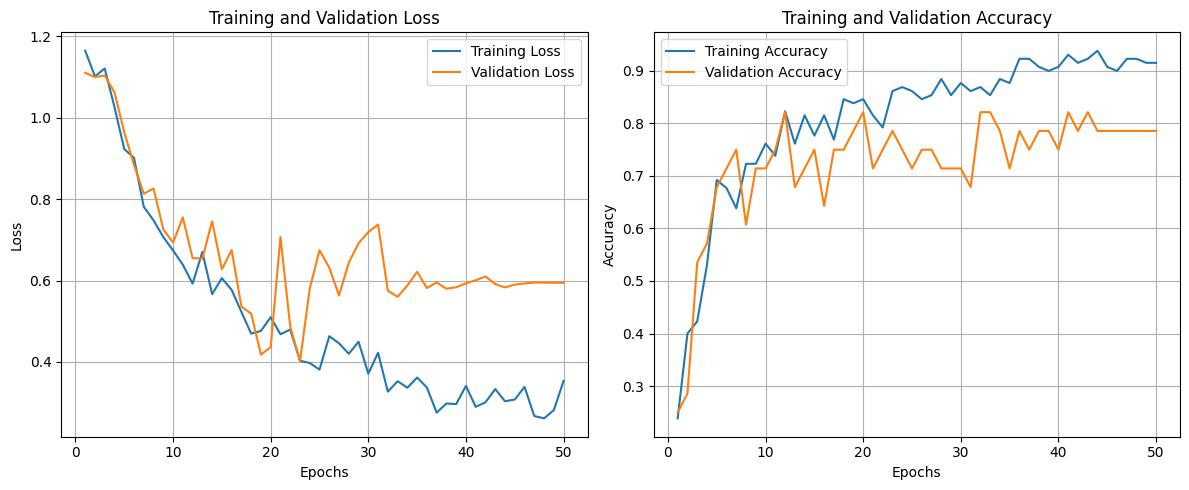

In [ ]:
# =================================================================
# PART 4: TRAINING & EVALUATION SCRIPT (WITH PLOTTING)
# =================================================================

# --- 1. Initialize Model and Optimizer with Best Parameters from Tuning ---
# Using the best parameters found by Optuna
# --- 1. Initialize Model and Optimizer with Best Parameters from Tuning ---
# Using the best parameters found by Optuna
# --- 1. Initialize Model and Optimizer with Best Parameters from Tuning ---
# Using the best parameters found by Optuna
best_params = {
    'lr': 0.0005453119303765244,
    'weight_decay': 3.1014266133504725e-06,
    'dropout_rate': 0.349516533031896,
    'clinical_feat_dim': 128,
    'biomarker_feat_dim': 128
}

# Instantiate the model. It will automatically load the correct MAE backbone and freeze it.
model = AdvancedMultiModalModel(
    clinical_feat_dim=best_params['clinical_feat_dim'],
    biomarker_feat_dim=best_params['biomarker_feat_dim']
).to(device)

# Create a filtered list of parameters that require gradients (i.e., are not frozen)
trainable_params = [p for p in model.parameters() if p.requires_grad]
print(f"Found {len(trainable_params)} parameters to train.")

# Setup optimizer with only the trainable parameters
optimizer = optim.AdamW(
    trainable_params,
    lr=best_params['lr'],
    weight_decay=best_params['weight_decay']
)

# --- 2. Training Setup ---
scheduler = CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-7)
class_weights = compute_class_weight('balanced', classes=np.unique(labels_train), y=labels_train)
criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float).to(device))
scaler = GradScaler()
NUM_EPOCHS = 50
PATIENCE = 15

# --- 3. Training Loop ---
# Lists to store metrics for plotting
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_val_accuracy = 0
for epoch in range(NUM_EPOCHS):
    model.train()

    # Variables to track loss and accuracy for the current epoch
    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for mri, clinical_seq, biomarker_seq, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        mri, clinical_seq, biomarker_seq, labels = mri.to(device), clinical_seq.to(device), biomarker_seq.to(device), labels.to(device)

        optimizer.zero_grad()
        with autocast():
            outputs = model(mri, clinical_seq, biomarker_seq)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Accumulate training loss and calculate accuracy
        running_train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    # Calculate and store average epoch metrics
    epoch_train_loss = running_train_loss / len(train_loader)
    epoch_train_acc = train_correct / train_total
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    model.eval()
    all_preds, all_labels = [], []
    running_val_loss = 0.0 # track validation loss

    with torch.no_grad():
        for mri, clinical_seq, biomarker_seq, labels in val_loader:
            mri, clinical_seq, biomarker_seq, labels = mri.to(device), clinical_seq.to(device), biomarker_seq.to(device), labels.to(device)
            outputs = model(mri, clinical_seq, biomarker_seq)

            # Calculate and accumulate validation loss
            val_loss = criterion(outputs, labels)
            running_val_loss += val_loss.item()

            all_preds.extend(torch.argmax(outputs, 1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calculate and store average validation metrics
    epoch_val_loss = running_val_loss / len(val_loader)
    val_losses.append(epoch_val_loss)
    val_acc = accuracy_score(all_labels, all_preds)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1} | Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        torch.save(model.state_dict(), FINAL_MODEL_PATH)
        print("⭐ New best model saved!")

    scheduler.step()

print("\n✅ Advanced Model Training Complete.")

# --- 4. PLOT TRAINING & VALIDATION CURVES ---
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, label='Training Loss')
plt.plot(range(1, NUM_EPOCHS + 1), val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, NUM_EPOCHS + 1), train_accuracies, label='Training Accuracy')
plt.plot(range(1, NUM_EPOCHS + 1), val_accuracies, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(TRAINING_PLOT_PATH) # Save the plot to the path defined in Part 1
plt.show()

Using device: cuda
✅ Paths and configurations are set.
✅ Test data, clinical, and biomarker sequences loaded.
✅ Test DataLoader created.
✅ Advanced Tri-Modal Model with Gated Fusion architecture defined.


/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.networks.nets.swin_unetr SwinUNETR.__init__:img_size: Argument `img_size` has been deprecated since version 1.3. It will be removed in version 1.5. The img_size argument is not required anymore and checks on the input size are run during forward().
  warn_deprecated(argname, msg, warning_category)


✅ Best model weights loaded successfully.


Testing:   0%|          | 0/4 [00:00<?, ?it/s]

✅ Inference on the test set is complete.

📊 Final Performance Report for Advanced Tri-Modal Model
  Metric  Score
Accuracy 0.8276
 AUC-ROC 0.9728
     MCC 0.7224
  G-Mean 0.8034

--- Detailed Classification Report ---
              precision    recall  f1-score   support

          CN       0.80      1.00      0.89         8
         MCI       0.67      0.33      0.44         6
    Dementia       0.88      0.93      0.90        15

    accuracy                           0.83        29
   macro avg       0.78      0.76      0.75        29
weighted avg       0.81      0.83      0.80        29



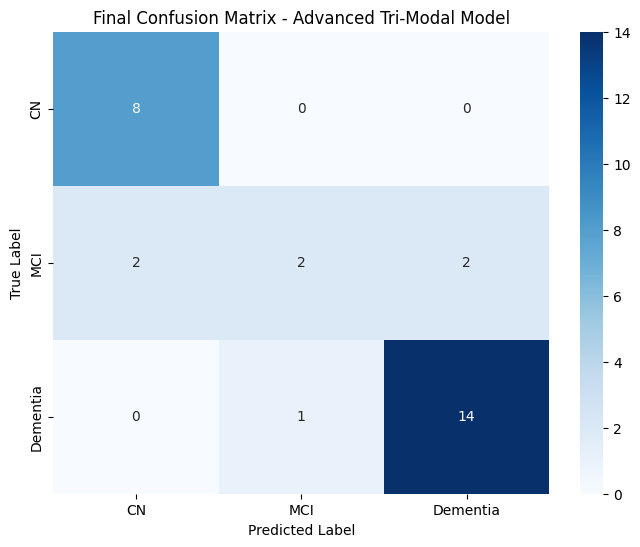

In [ ]:
# =================================================================
# FINAL EVALUATION SCRIPT FOR ADVANCED TRI-MODAL MODEL (OPTIMIZED)
# =================================================================

# --- 1. IMPORTS & SETUP ---
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from torch.utils.data import Dataset, DataLoader
import torchio as tio
from tqdm.notebook import tqdm
from sklearn.metrics import (
    classification_report, accuracy_score, confusion_matrix,
    roc_auc_score, matthews_corrcoef
)
from sklearn.preprocessing import label_binarize
from monai.networks.nets import SwinUNETR
from torch.nn.utils.rnn import pad_sequence

# --- Configuration & Paths ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
DRIVE_PROJECT_PATH = '<DRIVE_ROOT>/ADNI_NewDS/'
RESULTS_DIRECTORY = os.path.join(DRIVE_PROJECT_PATH, 'results')
PROCESSED_MRI_DIRECTORY = os.path.join(RESULTS_DIRECTORY, 'processed_mri_scans_swin')
SPLIT_IDS_PATH = os.path.join(RESULTS_DIRECTORY, 'patient_id_splits.npz')
CLEANED_DATA_PATH = os.path.join(RESULTS_DIRECTORY, 'project_data_cleaned.csv')
BIOMARKER_SEQUENCES_PATH = os.path.join(RESULTS_DIRECTORY, 'preprocessed_biomarker_sequences.npy')
FINAL_MODEL_PATH = os.path.join(RESULTS_DIRECTORY, 'advanced_multimodal_model.pth')
print("✅ Paths and configurations are set.")

# --- 2. LOAD TEST DATA & DATALOADER ---
# Load Data Splits and Cleaned Clinical Data
pid_splits = np.load(SPLIT_IDS_PATH, allow_pickle=True)
pids_test = pid_splits['pids_test']
labels_test = pid_splits['labels_test']

cleaned_df = pd.read_csv(CLEANED_DATA_PATH)
feature_columns = ['AGE', 'PTGENDER', 'PTEDUCAT', 'APOE4', 'MMSE', 'ADAS13', 'RAVLT_immediate', 'RAVLT_learning', 'RAVLT_forgetting', 'FAQ']
patient_sequences = {pid: torch.tensor(group[feature_columns].values, dtype=torch.float32) for pid, group in cleaned_df.groupby('PTID')}
biomarker_sequences = np.load(BIOMARKER_SEQUENCES_PATH, allow_pickle=True).item()
print("✅ Test data, clinical, and biomarker sequences loaded.")

# Define Multi-Modal Dataset and Transforms
IMG_SIZE = (96, 96, 96)
val_transform = tio.Compose([
    tio.Resize(IMG_SIZE),
    tio.ZNormalization(masking_method=tio.ZNormalization.mean)
])

# Dataset and Collate function
class MultiModalDataset(Dataset):
    def __init__(self, pids, labels, mri_dir, clinical_seq_dict, biomarker_seq_dict, transform=None):
        self.pids, self.labels = pids, torch.tensor(labels, dtype=torch.long)
        self.mri_dir = mri_dir
        self.sequences = clinical_seq_dict
        self.biomarker_sequences = biomarker_seq_dict
        self.transform = transform
    def __len__(self):
        return len(self.pids)
    def __getitem__(self, idx):
        pid, label = self.pids[idx], self.labels[idx]
        mri_path = os.path.join(self.mri_dir, f"{pid}_processed.npy")
        mri_scan = torch.tensor(np.load(mri_path), dtype=torch.float32).unsqueeze(0)
        subject = tio.Subject(mri=tio.ScalarImage(tensor=mri_scan))
        if self.transform:
            subject = self.transform(subject)
        return subject.mri.tensor.squeeze(0), self.sequences[pid], self.biomarker_sequences[pid], label

def collate_fn(batch):
    mri_tensors, clinical_sequences, biomarker_sequences, labels = zip(*batch)
    clinical_padded = pad_sequence(clinical_sequences, batch_first=True, padding_value=0)
    biomarker_padded = pad_sequence(biomarker_sequences, batch_first=True, padding_value=0)
    return torch.stack(mri_tensors), clinical_padded, biomarker_padded, torch.stack(labels)

# Create the Test DataLoader
test_dataset = MultiModalDataset(pids_test, labels_test, PROCESSED_MRI_DIRECTORY, patient_sequences, biomarker_sequences, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=2, collate_fn=collate_fn)
print("✅ Test DataLoader created.")


# --- 3. DEFINE THE ADVANCED MODEL ARCHITECTURE ---
# This must match the architecture you trained
class LSTMNet(nn.Module):
    def __init__(self, input_size=10, hidden_size=128, output_size=64):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True, num_layers=2, dropout=0.2)
        self.fc = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()
    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        return self.relu(self.fc(hn[-1]))

# UPDATED: The full Tri-Modal model definition with Gated Fusion
class AdvancedMultiModalModel(nn.Module):
    # UPDATED: Default values now reflect the best params found
    def __init__(self, num_classes=3, feature_size=48,
                 clinical_feat_dim=128, biomarker_feat_dim=128, dropout_rate=0.3495):
        super().__init__()
        vit_feature_size = feature_size * 16
        swin_unetr = SwinUNETR(in_channels=1, out_channels=1, img_size=IMG_SIZE, feature_size=feature_size)
        self.swin_vit_backbone = swin_unetr.swinViT
        self.swin_avg_pool = nn.AdaptiveAvgPool3d(1)
        self.image_feature_projection = nn.Linear(vit_feature_size, 256)
        self.lstm_branch_clinical = LSTMNet(input_size=10, output_size=clinical_feat_dim)
        self.lstm_branch_biomarker = LSTMNet(input_size=3, output_size=biomarker_feat_dim)
        self.fusion_gate = nn.Sequential(
            nn.Linear(256 + clinical_feat_dim + biomarker_feat_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 3),
            nn.Softmax(dim=1)
        )
        self.project_clinical = nn.Linear(clinical_feat_dim, 128)
        self.project_biomarker = nn.Linear(biomarker_feat_dim, 128)
        self.project_image = nn.Linear(256, 128)
        self.classifier = nn.Sequential(
            nn.LayerNorm(128),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout_rate), # Using the tuned dropout rate
            nn.Linear(64, num_classes)
        )

    def forward(self, mri_image, clinical_sequence, biomarker_sequence):
        swin_features = self.swin_vit_backbone(mri_image.unsqueeze(1))[-1]
        image_features = self.swin_avg_pool(swin_features).view(swin_features.size(0), -1)
        projected_image_features = self.image_feature_projection(image_features)
        clinical_features = self.lstm_branch_clinical(clinical_sequence)
        biomarker_features = self.lstm_branch_biomarker(biomarker_sequence)
        all_features_concat = torch.cat((projected_image_features, clinical_features, biomarker_features), dim=1)
        gates = self.fusion_gate(all_features_concat)
        img_proj = self.project_image(projected_image_features)
        clin_proj = self.project_clinical(clinical_features)
        bio_proj = self.project_biomarker(biomarker_features)
        fused_features = (gates[:, 0].unsqueeze(1) * img_proj +
                          gates[:, 1].unsqueeze(1) * clin_proj +
                          gates[:, 2].unsqueeze(1) * bio_proj)
        return self.classifier(fused_features)

print("✅ Advanced Tri-Modal Model with Gated Fusion architecture defined.")


# --- 4. LOAD BEST MODEL & RUN EVALUATION ---
# Initialize the model with the architecture that matches the saved weights
model = AdvancedMultiModalModel().to(device)
try:
    model.load_state_dict(torch.load(FINAL_MODEL_PATH))
    print("✅ Best model weights loaded successfully.")
except FileNotFoundError:
    print(f"ERROR: Model file not found at {FINAL_MODEL_PATH}. Please ensure the training completed and the file was saved correctly.")

model.eval()
all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for mri, clinical_seq, biomarker_seq, labels in tqdm(test_loader, desc="Testing"):
        mri, clinical_seq, biomarker_seq, labels = mri.to(device), clinical_seq.to(device), biomarker_seq.to(device), labels.to(device)
        outputs = model(mri, clinical_seq, biomarker_seq)
        probs = F.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

true_labels = np.array(all_labels)
final_preds = np.array(all_preds)
final_probs = np.array(all_probs)
print("✅ Inference on the test set is complete.")


# --- 5. CALCULATE & DISPLAY RESULTS ---
def calculate_g_mean(conf_matrix):
    g_means = []
    for i in range(conf_matrix.shape[0]):
        tp = conf_matrix[i, i]; fn = np.sum(conf_matrix[i, :]) - tp
        fp = np.sum(conf_matrix[:, i]) - tp; tn = np.sum(conf_matrix) - (tp + fn + fp)
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        g_means.append(np.sqrt(sensitivity * specificity))
    return np.mean(g_means)

print("\n📊 Final Performance Report for Advanced Tri-Modal Model")
true_labels_binarized = label_binarize(true_labels, classes=range(3))
accuracy = accuracy_score(true_labels, final_preds)
mcc = matthews_corrcoef(true_labels, final_preds)
auc_roc = roc_auc_score(true_labels_binarized, final_probs, multi_class='ovr', average='weighted')
cm = confusion_matrix(true_labels, final_preds)
g_mean = calculate_g_mean(cm)

report_df = pd.DataFrame({'Metric': ['Accuracy', 'AUC-ROC', 'MCC', 'G-Mean'], 'Score': [f"{accuracy:.4f}", f"{auc_roc:.4f}", f"{mcc:.4f}", f"{g_mean:.4f}"]})
print(report_df.to_string(index=False))

print("\n--- Detailed Classification Report ---")
label_map = {0: 'CN', 1: 'MCI', 2: 'Dementia'}
target_names = [label_map[i] for i in sorted(label_map.keys())]
print(classification_report(true_labels, final_preds, target_names=target_names, zero_division=0))

# --- Visualize Confusion Matrix ---
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Final Confusion Matrix - Advanced Tri-Modal Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
# ================================================================
# PART X: EVALUATION LOOP WITH CLASS-SPECIFIC THRESHOLDS
# ================================================================

model = AdvancedMultiModalModel(num_classes=3).to(device)
try:
    model.load_state_dict(torch.load(FINAL_MODEL_PATH, map_location=device))
    print("✅ Best model weights loaded successfully.")
except FileNotFoundError:
    print(f"❌ ERROR: Model file not found at {FINAL_MODEL_PATH}")
    raise

model.eval()
all_probs, all_labels = [], []

# --- NEW: Thresholding function ---
def predict_with_thresholds(probs, th_cn=0.50, th_mci=0.30, th_dem=0.50):
    """
    probs: numpy array [N,3] (softmax probabilities for [CN, MCI, Dementia])
    returns: numpy array of predictions after applying thresholds
    """
    preds = []
    for p in probs:
        if p[1] >= th_mci:                  # bias toward MCI if above its threshold
            preds.append(1)
        elif p[0] >= th_cn and p[0] == p.max():
            preds.append(0)                 # CN if above threshold and max
        elif p[2] >= th_dem and p[2] == p.max():
            preds.append(2)                 # Dementia if above threshold and max
        else:
            preds.append(p.argmax())        # fallback to argmax
    return np.array(preds)

with torch.no_grad():
    for mri, clinical_seq, biomarker_seq, labels in tqdm(test_loader, desc="Testing"):
        mri, clinical_seq, biomarker_seq, labels = (
            mri.to(device), clinical_seq.to(device), biomarker_seq.to(device), labels.to(device)
        )
        outputs = model(mri, clinical_seq, biomarker_seq)
        probs = F.softmax(outputs, dim=1)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# --- Apply thresholds here ---
true_labels = np.array(all_labels)
final_probs = np.array(all_probs)
final_preds = predict_with_thresholds(final_probs, th_cn=0.50, th_mci=0.30, th_dem=0.50)

print("✅ Inference on the test set (with class-specific thresholds) is complete.")


Attempting to load pre-trained backbone from: <DRIVE_ROOT>/ADNI_NewDS/results/mae_pretrain_backbone_final1.pth
✅ Pre-trained backbone weights loaded successfully.
✅ SwinViT backbone is frozen for initial fine-tuning.


RuntimeError: Error(s) in loading state_dict for AdvancedMultiModalModel:
	size mismatch for lstm_branch_clinical.fc.weight: copying a param with shape torch.Size([128, 128]) from checkpoint, the shape in current model is torch.Size([64, 128]).
	size mismatch for lstm_branch_clinical.fc.bias: copying a param with shape torch.Size([128]) from checkpoint, the shape in current model is torch.Size([64]).
	size mismatch for lstm_branch_biomarker.fc.weight: copying a param with shape torch.Size([128, 128]) from checkpoint, the shape in current model is torch.Size([64, 128]).
	size mismatch for lstm_branch_biomarker.fc.bias: copying a param with shape torch.Size([128]) from checkpoint, the shape in current model is torch.Size([64]).
	size mismatch for fusion_gate.0.weight: copying a param with shape torch.Size([256, 512]) from checkpoint, the shape in current model is torch.Size([256, 384]).
	size mismatch for project_clinical.weight: copying a param with shape torch.Size([128, 128]) from che

In [ ]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.0/247.0 kB 27.5 MB/s eta 0:00:00


In [ ]:
import optuna
from optuna.exceptions import TrialPruned
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import accuracy_score
from tqdm.notebook import tqdm

# =================================================================
# HYPERPARAMETER TUNING SCRIPT WITH OPTUNA
# =================================================================

# --- Objective Function ---
# This function defines one trial of the tuning process.
# Optuna will call this function many times.

def objective(trial):
    # --- 1. Define the hyperparameter search space ---
    # We ask the 'trial' object to suggest values for our parameters.
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    clinical_feat_dim = trial.suggest_categorical("clinical_feat_dim", [32, 64, 128])
    biomarker_feat_dim = trial.suggest_categorical("biomarker_feat_dim", [32, 64, 128])
    # The dropout rate in the final classifier is also a good parameter to tune
    # We will pass this to the model constructor later

    # --- 2. Build the model and optimizer with the suggested parameters ---
    model = AdvancedMultiModalModel(
        clinical_feat_dim=clinical_feat_dim,
        biomarker_feat_dim=biomarker_feat_dim
    ).to(device)

    # Filter for trainable parameters (everything except the frozen backbone)
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.AdamW(trainable_params, lr=lr, weight_decay=weight_decay)

    # --- 3. Setup for Training ---
    scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-7)
    class_weights = compute_class_weight('balanced', classes=np.unique(labels_train), y=labels_train)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float).to(device))
    scaler = GradScaler()

    # --- 4. Run the Training and Validation Loop ---
    best_val_accuracy = 0
    for epoch in range(NUM_EPOCHS):
        model.train()
        for mri, clinical_seq, biomarker_seq, labels in train_loader:
            mri, clinical_seq, biomarker_seq, labels = mri.to(device), clinical_seq.to(device), biomarker_seq.to(device), labels.to(device)
            optimizer.zero_grad()
            with autocast():
                outputs = model(mri, clinical_seq, biomarker_seq)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        # Validation phase
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for mri, clinical_seq, biomarker_seq, labels in val_loader:
                mri, clinical_seq, biomarker_seq, labels = mri.to(device), clinical_seq.to(device), biomarker_seq.to(device), labels.to(device)
                outputs = model(mri, clinical_seq, biomarker_seq)
                all_preds.extend(torch.argmax(outputs, 1).cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_accuracy = accuracy_score(all_labels, all_preds)

        # Update the best accuracy for this trial
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy

        # --- 5. Report intermediate results to Optuna for pruning ---
        trial.report(val_accuracy, epoch)
        if trial.should_prune():
            raise TrialPruned()

        scheduler.step()

    # --- 6. Return the final best validation accuracy for this trial ---
    return best_val_accuracy

# =================================================================
# Main Execution Block
# =================================================================

if __name__ == '__main__':
    # Assuming all your data loaders (train_loader, val_loader) and the
    # AdvancedMultiModalModel class are defined and available.
    NUM_EPOCHS = 25 # Use fewer epochs for tuning to save time

    # Create a pruner
    pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5, interval_steps=1)

    # Create the study
    # We want to MAXIMIZE validation accuracy
    study = optuna.create_study(direction="maximize", pruner=pruner)

    # Start the optimization
    # n_trials is the number of different hyperparameter combinations to test.
    # 50 is a good starting point.
    study.optimize(objective, n_trials=50)

    # Print the results
    print("\n\n========================================================")
    print("      ✨ Optuna Hyperparameter Tuning Complete ✨")
    print("========================================================")
    print(f"Number of finished trials: {len(study.trials)}")

    print("\n--- Best Trial ---")
    best_trial = study.best_trial
    print(f"  🏆 Best Validation Accuracy: {best_trial.value:.4f}")

    print("\n  📋 Best Hyperparameters:")
    for key, value in best_trial.params.items():
        print(f"    - {key}: {value}")

[I 2025-08-24 09:56:57,480] A new study created in memory with name: no-name-60bb7e59-a2d2-4859-a49d-0f22978f4b5c


Attempting to load pre-trained backbone from: <DRIVE_ROOT>/ADNI_NewDS/results/mae_pretrain_backbone_final1.pth
✅ Pre-trained backbone weights loaded successfully.
✅ SwinViT backbone is frozen for initial fine-tuning.


/tmp/ipython-input-2542172190.py:43: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipython-input-2542172190.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipython-input-2542172190.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipython-input-2542172190.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipython-input-2542172190.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipython-input-2542172190.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprec

Attempting to load pre-trained backbone from: <DRIVE_ROOT>/ADNI_NewDS/results/mae_pretrain_backbone_final1.pth
✅ Pre-trained backbone weights loaded successfully.
✅ SwinViT backbone is frozen for initial fine-tuning.


/tmp/ipython-input-2542172190.py:43: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipython-input-2542172190.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipython-input-2542172190.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipython-input-2542172190.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipython-input-2542172190.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipython-input-2542172190.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprec

...

Attempting to load pre-trained backbone from: <DRIVE_ROOT>/ADNI_NewDS/results/mae_pretrain_backbone_final1.pth
✅ Pre-trained backbone weights loaded successfully.
✅ SwinViT backbone is frozen for initial fine-tuning.


/tmp/ipython-input-2542172190.py:43: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipython-input-2542172190.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipython-input-2542172190.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipython-input-2542172190.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipython-input-2542172190.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipython-input-2542172190.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprec

Attempting to load pre-trained backbone from: <DRIVE_ROOT>/ADNI_NewDS/results/mae_pretrain_backbone_final1.pth
✅ Pre-trained backbone weights loaded successfully.
✅ SwinViT backbone is frozen for initial fine-tuning.


/tmp/ipython-input-2542172190.py:43: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipython-input-2542172190.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipython-input-2542172190.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipython-input-2542172190.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipython-input-2542172190.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipython-input-2542172190.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprec

KeyboardInterrupt: 